# Transformer 高光谱分类教学 Notebook

这份 Notebook 以 `Indian Pines` 为例，演示如何用 **Transformer** 处理高光谱像素分类。

这里采用的是一个教学型、轻量的光谱 Transformer：

- 把每个像素的光谱向量看作一个序列
- 把每个波段值映射为 token 表示
- 通过自注意力建模不同波段之间的依赖关系


## 背景说明

Transformer 在高光谱分类中的一个重要思路，是把高光谱数据重新理解为**序列建模问题**。

这里的教学实现受到 SpectralFormer 的思路启发：

- 论文：*SpectralFormer: Rethinking Hyperspectral Image Classification With Transformers*
- 代码：`danfenghong/IEEE_TGRS_SpectralFormer`

本 Notebook 不复刻完整论文结构，而是实现一个更容易理解和运行的教学版本。


In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


## 1. 读取数据


In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"]
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"]

class_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers']

print("cube shape:", cube.shape)
print("gt shape:", gt.shape)
print("dtype:", cube.dtype, gt.dtype)
print("num classes:", len(class_names))
print("labeled pixels:", int((gt != 0).sum()))


cube shape: (145, 145, 200)
gt shape: (145, 145)
dtype: uint16 uint8
num classes: 16
labeled pixels: 10249


In [3]:
unique, counts = np.unique(gt, return_counts=True)
class_count_df = pd.DataFrame({"label": unique, "count": counts})
class_count_df = class_count_df[class_count_df["label"] != 0].copy()
class_count_df["class_name"] = class_count_df["label"].apply(lambda x: class_names[x - 1])
class_count_df = class_count_df[["label", "class_name", "count"]].sort_values("label")
class_count_df


,label,class_name,count
1,1,Alfalfa,46
2,2,Corn-notill,1428
3,3,Corn-mintill,830
4,4,Corn,237
5,5,Grass-pasture,483
6,6,Grass-trees,730
7,7,Grass-pasture-mowed,28
8,8,Hay-windrowed,478
9,9,Oats,20
10,10,Soybean-notill,972


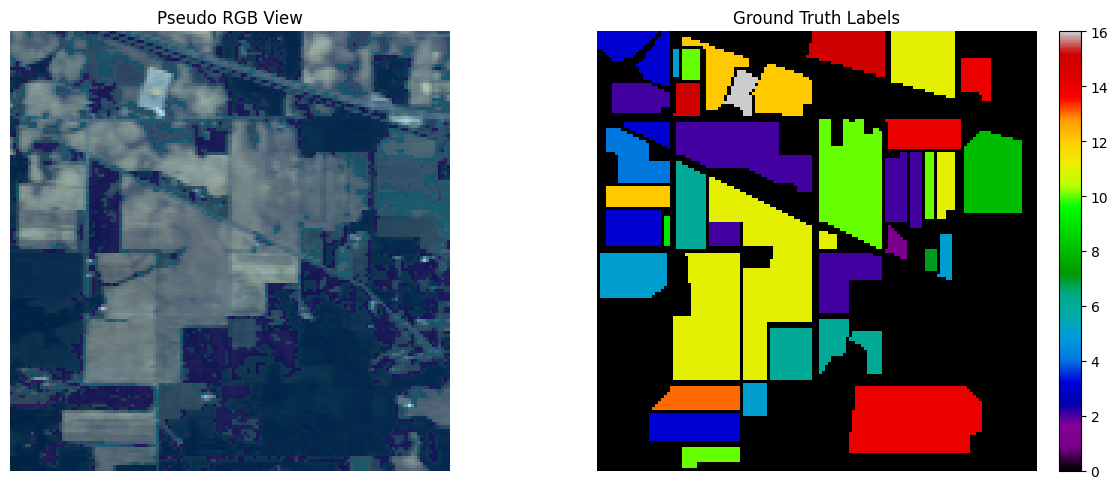

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb = cube[:, :, [29, 19, 9]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB View")
axes[0].axis("off")

im = axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth Labels")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 2. 构造像素级光谱序列

与 1D CNN 类似，这里按像素做分类。
区别在于：1D CNN 用卷积提取局部光谱模式，而 Transformer 用自注意力建模波段间关系。


In [5]:
mask = gt != 0
positions = np.argwhere(mask)
X = cube[mask].astype(np.float32)
y = gt[mask].astype(np.int64) - 1

print("X shape:", X.shape)
print("y shape:", y.shape)
print("bands per pixel:", X.shape[1])


X shape: (10249, 200)
y shape: (10249,)
bands per pixel: 200


## 3. 划分训练 / 验证 / 测试集


In [6]:
TRAIN_RATIO = 0.1
VAL_RATIO = 0.1
TEST_RATIO = 0.8

X_train, X_temp, y_train, y_temp, pos_train, pos_temp = train_test_split(
    X,
    y,
    positions,
    train_size=TRAIN_RATIO,
    stratify=y,
    random_state=SEED,
)

val_ratio_within_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
X_val, X_test, y_val, y_test, pos_val, pos_test = train_test_split(
    X_temp,
    y_temp,
    pos_temp,
    train_size=val_ratio_within_temp,
    stratify=y_temp,
    random_state=SEED,
)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)


train: (1024, 200) (1024,)
val:   (1025, 200) (1025,)
test:  (8200, 200) (8200,)


In [7]:
def count_by_class(labels, class_names):
    values, counts = np.unique(labels, return_counts=True)
    rows = []
    for v, c in zip(values, counts):
        rows.append({"label": int(v + 1), "class_name": class_names[v], "count": int(c)})
    return pd.DataFrame(rows)


split_summary = pd.concat(
    [
        count_by_class(y_train, class_names).assign(split="train"),
        count_by_class(y_val, class_names).assign(split="val"),
        count_by_class(y_test, class_names).assign(split="test"),
    ],
    ignore_index=True,
)

split_summary.head(12)


,label,class_name,count,split
0,1,Alfalfa,5,train
1,2,Corn-notill,143,train
2,3,Corn-mintill,83,train
3,4,Corn,24,train
4,5,Grass-pasture,48,train
5,6,Grass-trees,73,train
6,7,Grass-pasture-mowed,3,train
7,8,Hay-windrowed,48,train
8,9,Oats,2,train
9,10,Soybean-notill,97,train


## 4. 标准化与 DataLoader

这里先对光谱向量做标准化，再送入 Transformer。


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
X_all_scaled = scaler.transform(X).astype(np.float32)

BATCH_SIZE = 256

train_ds = TensorDataset(torch.from_numpy(X_train_scaled), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val_scaled), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test_scaled), torch.from_numpy(y_test))
all_ds = TensorDataset(torch.from_numpy(X_all_scaled), torch.from_numpy(y))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
all_loader = DataLoader(all_ds, batch_size=BATCH_SIZE, shuffle=False)

next(iter(train_loader))[0].shape


torch.Size([256, 200])

## 5. 定义光谱 Transformer

这里把每个波段值视为一个 token：

- 输入形状：`(batch, bands)`
- 先把每个标量波段值投影到 `d_model`
- 再加位置编码
- 再送入 Transformer Encoder


In [9]:
class SpectralTransformerClassifier(nn.Module):
    def __init__(self, num_bands, num_classes, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.band_proj = nn.Linear(1, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, num_bands, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.band_proj(x)
        x = x + self.pos_embed
        x = self.encoder(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.classifier(x)


model = SpectralTransformerClassifier(num_bands=X_train_scaled.shape[1], num_classes=len(class_names)).to(device)
model


SpectralTransformerClassifier(
  (band_proj): Linear(in_features=1, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0

In [10]:
@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    total_correct = 0
    total_count = 0

    for batch in data_loader:
        xb, yb = batch
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += yb.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    acc = total_correct / total_count
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return acc, y_true, y_pred


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
}


## 6. 训练模型


In [11]:
best_state = None
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_acc, _, _ = evaluate_model(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

print("best_val_acc =", round(best_val_acc, 4))


Epoch 01/10 | loss=2.7032 | train_acc=0.1807 | val_acc=0.2468


Epoch 02/10 | loss=2.4846 | train_acc=0.2871 | val_acc=0.3541


Epoch 03/10 | loss=2.3265 | train_acc=0.3613 | val_acc=0.3795


Epoch 04/10 | loss=2.1959 | train_acc=0.3867 | val_acc=0.3932


Epoch 05/10 | loss=2.0792 | train_acc=0.3926 | val_acc=0.3951


Epoch 06/10 | loss=1.9842 | train_acc=0.3945 | val_acc=0.4029


Epoch 07/10 | loss=1.8970 | train_acc=0.3945 | val_acc=0.4020


Epoch 08/10 | loss=1.8184 | train_acc=0.4014 | val_acc=0.4059


Epoch 09/10 | loss=1.7460 | train_acc=0.4072 | val_acc=0.4059


Epoch 10/10 | loss=1.6969 | train_acc=0.4131 | val_acc=0.4205
best_val_acc = 0.4205


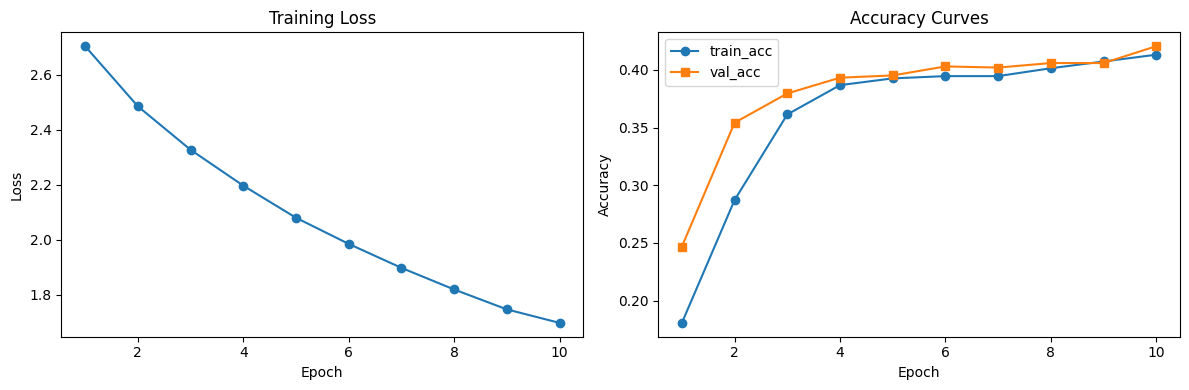

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch_index = np.arange(1, EPOCHS + 1)
axes[0].plot(epoch_index, history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epoch_index, history["train_acc"], marker="o", label="train_acc")
axes[1].plot(epoch_index, history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. 测试集评估


In [13]:
model.load_state_dict(best_state)
model.to(device)

test_acc, y_true_test, y_pred_test = evaluate_model(model, test_loader, device)
oa = accuracy_score(y_true_test, y_pred_test)
aa = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
kappa = cohen_kappa_score(y_true_test, y_pred_test)

print("Test accuracy:", round(test_acc, 4))
print("OA:", round(oa, 4))
print("AA:", round(aa, 4))
print("Kappa:", round(kappa, 4))


Test accuracy: 0.4233
OA: 0.4233
AA: 0.1861
Kappa: 0.292


In [14]:
report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report)


                              precision    recall  f1-score   support

                     Alfalfa     0.0000    0.0000    0.0000        37
                 Corn-notill     0.5647    0.0841    0.1463      1142
                Corn-mintill     0.0000    0.0000    0.0000       664
                        Corn     0.0000    0.0000    0.0000       189
               Grass-pasture     0.0000    0.0000    0.0000       387
                 Grass-trees     0.3993    0.7466    0.5203       584
         Grass-pasture-mowed     0.0000    0.0000    0.0000        22
               Hay-windrowed     0.7670    0.2068    0.3258       382
                        Oats     0.0000    0.0000    0.0000        16
              Soybean-notill     0.0682    0.0039    0.0073       778
             Soybean-mintill     0.3761    0.9420    0.5376      1965
               Soybean-clean     0.0000    0.0000    0.0000       475
                       Wheat     0.0000    0.0000    0.0000       164
                   

## 8. 整图预测


In [15]:
@torch.no_grad()
def predict_all(model, data_loader):
    model.eval()
    preds = []
    for xb, _ in data_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


all_pred = predict_all(model, all_loader)
pred_map = np.zeros_like(gt)
pred_map[positions[:, 0], positions[:, 1]] = all_pred + 1

print("pred_map shape:", pred_map.shape)
print("nonzero predictions:", int((pred_map != 0).sum()))


pred_map shape: (145, 145)
nonzero predictions: 10249


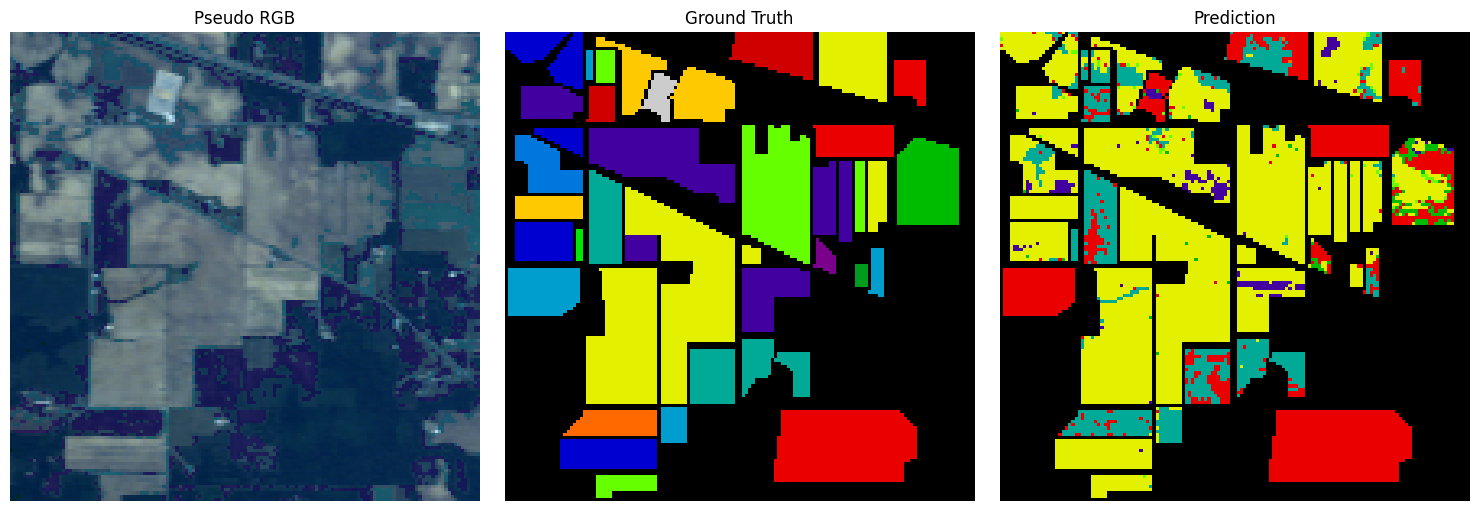

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB")
axes[0].axis("off")

axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 9. 保存结果


In [17]:
output_dir = Path("results/transformer/IP_notebook")
output_dir.mkdir(parents=True, exist_ok=True)

metrics = {
    "seed": SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "oa": float(oa),
    "aa": float(aa),
    "kappa": float(kappa),
    "best_val_acc": float(best_val_acc),
}

(output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(output_dir / "classification_report.txt").write_text(report, encoding="utf-8")
split_summary.to_csv(output_dir / "split_summary.csv", index=False)
class_count_df.to_csv(output_dir / "class_distribution.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].plot(np.arange(1, EPOCHS + 1), history["train_acc"], marker="o", label="train_acc")
axes[1].plot(np.arange(1, EPOCHS + 1), history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
fig.savefig(output_dir / "training_curves.png", dpi=200)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Prediction")
axes[1].axis("off")
plt.tight_layout()
fig.savefig(output_dir / "prediction_map.png", dpi=200)
plt.close(fig)

print("saved to", output_dir)
print(sorted(p.name for p in output_dir.iterdir()))


saved to results\transformer\IP_notebook
['class_distribution.csv', 'classification_report.txt', 'metrics.json', 'prediction_map.png', 'split_summary.csv', 'training_curves.png']


## 10. 小结

Transformer 的教学意义在于：

- 它提供了一种不同于 CNN 的高光谱建模视角
- 重点不再是卷积提取局部模式，而是波段之间的关系建模
- 很适合作为理解光谱序列建模的入门样例
